# Cultural rules + capability-vs-rule: EN/HI

Two independent analyses in this notebook, sharing one loaded model. Nothing here re-runs the `active_cancelled` experiment from the first notebook.

**A. Cultural rules (`tone_norm`)** — 7 clauses, 2/2/3 easy/medium/hard (the formality-register rule added to the hard tier), EN+HI, 21 rows each language. Same three-part test as before (language-of-thought, rule-vs-language entanglement, cross-lingual transfer), run on `tone_norm` instead of `active_cancelled`, plus a breakdown by difficulty tier since that's what the graded structure is for. Compare the resulting transfer numbers against the earlier `active_cancelled` baseline (best layer 12, AUC 0.683) — that comparison is the actual answer to "does culture add variance beyond language."

**B. Capability vs. rule (`word_count`)** — now EN+HI complete. Generates the no-rule capability baseline and the real rule-framed responses in both languages, reports the adherence-vs-capability gap per target count per language, then runs the mechanistic stability check (does the rule direction hold up regardless of counting ability) on real activations, in both languages.

**Honest caveat, same as always**: built and unit-tested against synthetic data, not run against the real model here — no GPU/HF access in the environment that wrote it.

## Setup

Same RAM-safe loading as the first notebook — `AutoModelForCausalLM(..., low_cpu_mem_usage=True)` into `HookedTransformer.from_pretrained(hf_model=...)`, `bfloat16` not TransformerLens's `float32` default, `names_filter` + `device="cpu"` on every `run_with_cache`. If you're running this in the same Colab session as the first notebook, skip straight to the data-loading cells and reuse the already-loaded `model`.

In [1]:
!pip install -q transformer_lens scikit-learn matplotlib huggingface_hub

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.3 MB/s eta 0:00:00


In [2]:
import json
import os
import re
import unicodedata

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"   # 1B per the working setup; swap to 3B if you've retested the RAM fix at that size
DTYPE = torch.bfloat16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

# os.environ["HF_TOKEN"] = "hf_..."   # uncomment if not already authenticated this session

In [3]:
os.environ["HF_TOKEN"] = "Add yours"

In [4]:
import gc

def print_mem(label):
    try:
        with open("/proc/meminfo") as f:
            lines = f.read()
        avail = [l for l in lines.splitlines() if l.startswith("MemAvailable")][0]
        print(f"[{label}] {avail.strip()}")
    except FileNotFoundError:
        pass

from transformers import AutoModelForCausalLM, AutoTokenizer

print_mem("before hf_model load")
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,   # meta-device loading -- avoids the fp32-then-fp32-again double allocation
)
print_mem("after hf_model load")

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    hf_model=hf_model,
    tokenizer=hf_tokenizer,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,                # off: this is the actual fix -- without these four, TransformerLens
    center_writing_weights=False, # builds derived/reparameterized tensors alongside the originals
    center_unembed=False,         # during conversion, spiking peak RAM right at this line. Matches
    fold_value_biases=False,      # TransformerLens's own large-LLaMA demo loading pattern.
)
print_mem("after HookedTransformer conversion")

model.eval()
del hf_model, hf_tokenizer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print_mem("after cleanup")

N_LAYERS = model.cfg.n_layers
D_MODEL = model.cfg.d_model
print(f"{MODEL_NAME}: {N_LAYERS} layers, d_model={D_MODEL}, device={DEVICE}")

[before hf_model load] MemAvailable:    8451704 kB


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

[after hf_model load] MemAvailable:   10513112 kB


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
[after HookedTransformer conversion] MemAvailable:    8768844 kB
[after cleanup] MemAvailable:    8769656 kB
meta-llama/Llama-3.2-1B-Instruct: 16 layers, d_model=2048, device=cuda


## Core analysis functions -- unit-tested before touching real activations

In [5]:
def diff_in_means(active_acts, revoked_acts, center=False):
    active_acts = np.asarray(active_acts, dtype=np.float64)
    revoked_acts = np.asarray(revoked_acts, dtype=np.float64)
    if center:
        pooled = np.concatenate([active_acts, revoked_acts], axis=0).mean(axis=0)
        active_acts, revoked_acts = active_acts - pooled, revoked_acts - pooled
    return active_acts.mean(axis=0) - revoked_acts.mean(axis=0)

def cosine_sim(a, b):
    a, b = np.asarray(a, dtype=np.float64), np.asarray(b, dtype=np.float64)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom else 0.0

def zero_shot_transfer_auc(source_direction, target_active, target_revoked):
    proj_a = np.asarray(target_active, dtype=np.float64) @ source_direction
    proj_r = np.asarray(target_revoked, dtype=np.float64) @ source_direction
    y = np.concatenate([np.ones(len(proj_a)), np.zeros(len(proj_r))])
    scores = np.concatenate([proj_a, proj_r])
    return float(roc_auc_score(y, scores)) if len(set(y)) > 1 else float("nan")

def same_language_upper_bound_auc(active_acts, revoked_acts, n_splits=5, seed=0):
    active_acts = np.asarray(active_acts, dtype=np.float64); revoked_acts = np.asarray(revoked_acts, dtype=np.float64)
    X = np.concatenate([active_acts, revoked_acts], axis=0)
    y = np.concatenate([np.ones(len(active_acts)), np.zeros(len(revoked_acts))])
    n_splits = min(n_splits, int(min(np.bincount(y.astype(int)))))
    if n_splits < 2:
        return float("nan")
    clf = SVC(kernel="linear", C=1.0)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = []
    for tr, te in skf.split(X, y):
        clf.fit(X[tr], y[tr])
        if len(np.unique(y[te])) < 2: continue
        aucs.append(roc_auc_score(y[te], clf.decision_function(X[te])))
    return float(np.mean(aucs)) if aucs else float("nan")

def transfer_gap(source_direction, target_active, target_revoked, n_splits=5, seed=0):
    upper = same_language_upper_bound_auc(target_active, target_revoked, n_splits, seed)
    transferred = zero_shot_transfer_auc(source_direction, target_active, target_revoked)
    return {"same_language_upper_bound_auc": upper, "cross_lingual_transfer_auc": transferred,
            "transfer_gap": (upper - transferred) if not np.isnan(upper) else float("nan")}

def stability_check(active_acts, revoked_acts, mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.sum() < 2 or (~mask).sum() < 2:
        return {"cosine_similarity": float("nan"), "note": "not enough rows in one group"}
    ds = diff_in_means(active_acts[mask], revoked_acts[mask])
    df = diff_in_means(active_acts[~mask], revoked_acts[~mask])
    return {"cosine_similarity": cosine_sim(ds, df), "n_capable": int(mask.sum()), "n_incapable": int((~mask).sum())}

def script_fractions(token_strs):
    counts = {"devanagari": 0, "latin": 0, "other": 0}; total = 0
    for tok in token_strs:
        for ch in tok:
            if not ch.isalpha(): continue
            total += 1
            try: name = unicodedata.name(ch)
            except ValueError: counts["other"] += 1; continue
            if "DEVANAGARI" in name: counts["devanagari"] += 1
            elif "LATIN" in name: counts["latin"] += 1
            else: counts["other"] += 1
    return {k: (v/total if total else 0.0) for k, v in counts.items()}

RESID_POST_FILTER = lambda name: name.endswith("hook_resid_post")

@torch.no_grad()
def get_layerwise_activations_and_logit_lens(model, system_text, user_text, k=20):
    """
    Single forward pass, returns BOTH the raw per-layer activations AND the
    logit-lens top-k tokens. The two were separate functions doing separate
    forward passes on the same prompt before -- this halves Section A's
    forward-pass count for no loss of information.
    """
    prompt = model.tokenizer.apply_chat_template(
        [{"role": "system", "content": system_text}, {"role": "user", "content": user_text}],
        tokenize=False, add_generation_prompt=True)
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(tokens, names_filter=RESID_POST_FILTER, device="cpu", return_type=None)

    acts = np.zeros((model.cfg.n_layers, model.cfg.d_model), dtype=np.float32)
    ln_final_cpu = model.ln_final.to("cpu")
    W_U_cpu, b_U_cpu = model.W_U.to("cpu"), model.b_U.to("cpu")
    per_layer_tokens = []
    for layer in range(model.cfg.n_layers):
        resid = cache["resid_post", layer][:, -1:, :]
        acts[layer] = resid[0, 0, :].float().numpy()
        logits = (ln_final_cpu(resid) @ W_U_cpu + b_U_cpu).squeeze()
        top_ids = torch.topk(logits, k).indices.tolist()
        per_layer_tokens.append([model.tokenizer.decode([tid]) for tid in top_ids])

    del cache, tokens
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return acts, per_layer_tokens

# kept as a thin wrapper so Section B's activation-only calls (which don't need
# logit-lens) don't pay for computing it
@torch.no_grad()
def get_layerwise_activations(model, system_text, user_text):
    acts, _ = get_layerwise_activations_and_logit_lens(model, system_text, user_text, k=1)
    return acts


@torch.no_grad()
def generate_text(model, system_text, user_text, max_new_tokens=20):
    """max_new_tokens dropped from 60 -> 20 by default: word_count tasks here only
    ever need 3-7 words (roughly 5-10 tokens), 60 was 6-10x more generation than
    the task needs, on every single call. Cleanup added -- this was the actual
    bug causing the crash: the other two extraction functions clear the CUDA
    cache after every call, this one didn't, so it leaked a little on every one
    of the ~130 generation calls in Section B regardless of how many rows you run."""
    prompt = model.tokenizer.apply_chat_template(
        [{"role": "system", "content": system_text}, {"role": "user", "content": user_text}],
        tokenize=False, add_generation_prompt=True)
    tokens = model.to_tokens(prompt)
    out_tokens = model.generate(tokens, max_new_tokens=max_new_tokens, do_sample=False,
                                  verbose=False, use_past_kv_cache=True)
    text = model.tokenizer.decode(out_tokens[0, tokens.shape[1]:], skip_special_tokens=True)
    del tokens, out_tokens
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return text

### Sanity check -- run this before trusting anything below

In [6]:
rng = np.random.default_rng(0)
d, n = 64, 60
true_dir = rng.normal(size=d); true_dir /= np.linalg.norm(true_dir)
mask = np.array([True]*(n//2) + [False]*(n//2))
active = np.zeros((n, d)); revoked = np.zeros((n, d))
for i in range(n):
    noise = 0.15 if mask[i] else 0.6
    active[i] = true_dir*2.0 + rng.normal(size=d)*noise
    revoked[i] = rng.normal(size=d)*noise
r = stability_check(active, revoked, mask)
print(f"Stability check, stable-signal case: cosine={r['cosine_similarity']:.3f} (expect high, >0.6)")
assert r["cosine_similarity"] > 0.6

other = rng.normal(size=d); other /= np.linalg.norm(other)
active2 = np.zeros((n, d)); revoked2 = np.zeros((n, d))
for i in range(n):
    dvec = true_dir if mask[i] else other
    active2[i] = dvec*2.0 + rng.normal(size=d)*0.15
    revoked2[i] = rng.normal(size=d)*0.15
r2 = stability_check(active2, revoked2, mask)
print(f"Stability check, contaminated case: cosine={r2['cosine_similarity']:.3f} (expect low, <0.3)")
assert r2["cosine_similarity"] < 0.3
print("Sanity checks passed.")

Stability check, stable-signal case: cosine=0.870 (expect high, >0.6)
Stability check, contaminated case: cosine=0.032 (expect low, <0.3)
Sanity checks passed.


---
# A. Cultural rules (`tone_norm`)

In [7]:
def load_pairs(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)["pairs"]

tone_en = load_pairs("tone_norm_graded_en.json") + load_pairs("tone_norm_formality_en.json")
tone_hi = load_pairs("tone_norm_graded_hi.json") + load_pairs("tone_norm_formality_hi.json")
assert len(tone_en) == 21 and len(tone_hi) == 21

hi_by_en_id = {r["en_pair_id"]: r for r in tone_hi}
tone_pairs = [(en, hi_by_en_id[en["id"]]) for en in tone_en if en["id"] in hi_by_en_id]
assert len(tone_pairs) == 21, "EN/HI alignment lost rows -- check en_pair_id"
print(f"{len(tone_pairs)} aligned tone_norm EN/HI pairs, tiers: "
      f"{sorted(set(en['topic'] for en, _ in tone_pairs))}")

21 aligned tone_norm EN/HI pairs, tiers: ['finance_easy', 'finance_hard', 'finance_medium']


In [8]:
import gc

# Set to a small number (e.g. 4) for a fast end-to-end smoke test before
# committing to the full run -- None uses everything.
ROW_LIMIT = None
pairs_to_run = tone_pairs[:ROW_LIMIT] if ROW_LIMIT else tone_pairs

tone_results = {"en_active": [], "en_revoked": [], "hi_active": [], "hi_revoked": []}
tone_logit_lens = {"en": [], "hi": []}
tone_tiers = []

for idx, (en_row, hi_row) in enumerate(pairs_to_run):
    a, ll = get_layerwise_activations_and_logit_lens(model, en_row["system_rule"], en_row["user_query"])
    tone_results["en_active"].append(a); tone_logit_lens["en"].append(ll)
    a, _ = get_layerwise_activations_and_logit_lens(model, en_row["system_non_rule"], en_row["user_query"], k=1)
    tone_results["en_revoked"].append(a)
    a, ll = get_layerwise_activations_and_logit_lens(model, hi_row["system_rule"], hi_row["user_query"])
    tone_results["hi_active"].append(a); tone_logit_lens["hi"].append(ll)
    a, _ = get_layerwise_activations_and_logit_lens(model, hi_row["system_non_rule"], hi_row["user_query"], k=1)
    tone_results["hi_revoked"].append(a)
    tone_tiers.append(en_row["topic"])

    if (idx + 1) % 5 == 0:
        gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
        print(f"  {idx+1}/{len(pairs_to_run)} pairs done")

for k in tone_results:
    tone_results[k] = np.stack(tone_results[k])
    print(k, tone_results[k].shape)
tone_tiers = np.array(tone_tiers)

  5/21 pairs done
  10/21 pairs done
  15/21 pairs done
  20/21 pairs done
en_active (21, 16, 2048)
en_revoked (21, 16, 2048)
hi_active (21, 16, 2048)
hi_revoked (21, 16, 2048)


## A1. Language-of-thought on tone_norm

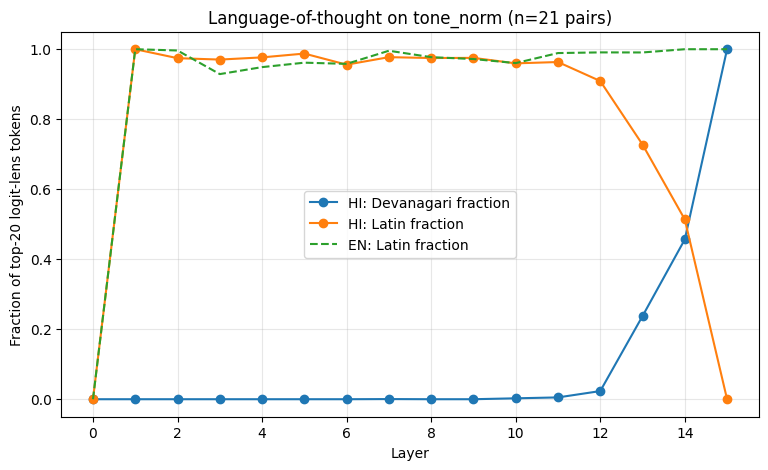

Compare the layer where this crosses over against active_cancelled's (13-15) -- 
same crossover point on a different rule category is a much stronger claim than one category alone.


In [9]:
def mean_script_fraction_by_layer(topk_runs, script="devanagari"):
    n_layers = len(topk_runs[0])
    fracs = np.zeros((len(topk_runs), n_layers))
    for i, run in enumerate(topk_runs):
        for layer, toks in enumerate(run):
            fracs[i, layer] = script_fractions(toks)[script]
    return fracs.mean(axis=0)

hi_dev = mean_script_fraction_by_layer(tone_logit_lens["hi"], "devanagari")
hi_lat = mean_script_fraction_by_layer(tone_logit_lens["hi"], "latin")
en_lat = mean_script_fraction_by_layer(tone_logit_lens["en"], "latin")

layers = np.arange(N_LAYERS)
plt.figure(figsize=(9, 5))
plt.plot(layers, hi_dev, label="HI: Devanagari fraction", marker="o")
plt.plot(layers, hi_lat, label="HI: Latin fraction", marker="o")
plt.plot(layers, en_lat, label="EN: Latin fraction", linestyle="--")
plt.xlabel("Layer"); plt.ylabel("Fraction of top-20 logit-lens tokens")
plt.title("Language-of-thought on tone_norm (n=21 pairs)")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Compare the layer where this crosses over against active_cancelled's (13-15) -- ")
print("same crossover point on a different rule category is a much stronger claim than one category alone.")

## A2. Cross-lingual transfer on tone_norm, overall and by difficulty tier

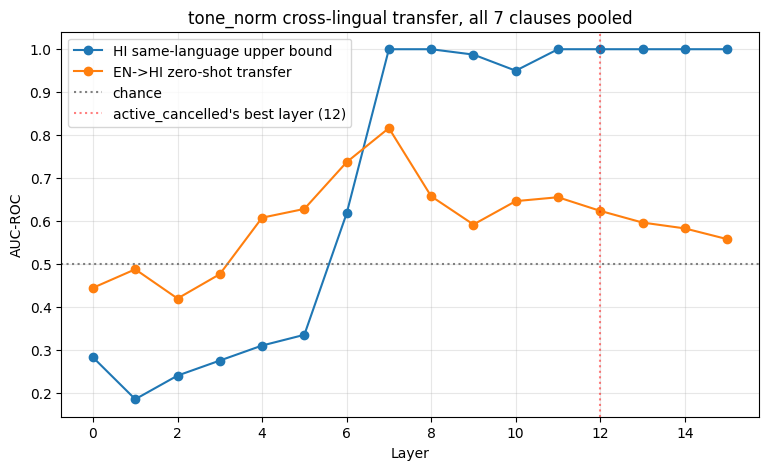

Best tone_norm transfer: layer 7, AUC=0.816 (upper bound 1.000)
active_cancelled baseline for comparison: layer 12, AUC=0.683 (upper bound 1.000)
Lower transfer here than active_cancelled = culture adds variance beyond language.
Same or higher = the earlier result generalizes past one formal rule category.

--- Same thing, split by difficulty tier (finance_easy/medium/hard) ---
  finance_easy (n=6): best transfer layer 7, AUC=0.861
  finance_hard (n=9): best transfer layer 7, AUC=0.852
  finance_medium (n=6): best transfer layer 10, AUC=1.000
If hard-tier transfer is consistently lower than easy-tier, that's the direct, quantified
answer to whether subtle/culturally-loaded judgments are harder to share across languages
than clear-cut ones -- small n per tier here (6-9 rows), read as a first signal not a conclusion.


In [10]:
tone_transfer = []
for layer in range(N_LAYERS):
    rule_dir_en = diff_in_means(tone_results["en_active"][:, layer], tone_results["en_revoked"][:, layer])
    r = transfer_gap(rule_dir_en, tone_results["hi_active"][:, layer], tone_results["hi_revoked"][:, layer])
    r["layer"] = layer
    tone_transfer.append(r)

upper = [r["same_language_upper_bound_auc"] for r in tone_transfer]
transferred = [r["cross_lingual_transfer_auc"] for r in tone_transfer]
plt.figure(figsize=(9, 5))
plt.plot(layers, upper, label="HI same-language upper bound", marker="o")
plt.plot(layers, transferred, label="EN->HI zero-shot transfer", marker="o")
plt.axhline(0.5, color="gray", linestyle=":", label="chance")
plt.axvline(12, color="red", linestyle=":", alpha=0.5, label="active_cancelled's best layer (12)")
plt.xlabel("Layer"); plt.ylabel("AUC-ROC")
plt.title("tone_norm cross-lingual transfer, all 7 clauses pooled")
plt.legend(); plt.grid(alpha=0.3); plt.show()

best_layer = int(np.nanargmax(transferred))
print(f"Best tone_norm transfer: layer {best_layer}, AUC={transferred[best_layer]:.3f} "
      f"(upper bound {upper[best_layer]:.3f})")
print(f"active_cancelled baseline for comparison: layer 12, AUC=0.683 (upper bound 1.000)")
print("Lower transfer here than active_cancelled = culture adds variance beyond language.")
print("Same or higher = the earlier result generalizes past one formal rule category.")

print("\n--- Same thing, split by difficulty tier (finance_easy/medium/hard) ---")
for tier in sorted(set(tone_tiers)):
    idx = tone_tiers == tier
    if idx.sum() < 2:
        print(f"  {tier}: too few rows to split reliably (n={idx.sum()})"); continue
    layer_aucs = []
    for layer in range(N_LAYERS):
        rd = diff_in_means(tone_results["en_active"][idx, layer], tone_results["en_revoked"][idx, layer])
        auc = zero_shot_transfer_auc(rd, tone_results["hi_active"][idx, layer], tone_results["hi_revoked"][idx, layer])
        layer_aucs.append(auc)
    best = int(np.nanargmax(layer_aucs))
    print(f"  {tier} (n={idx.sum()}): best transfer layer {best}, AUC={layer_aucs[best]:.3f}")
print("If hard-tier transfer is consistently lower than easy-tier, that's the direct, quantified")
print("answer to whether subtle/culturally-loaded judgments are harder to share across languages")
print("than clear-cut ones -- small n per tier here (6-9 rows), read as a first signal not a conclusion.")

---
# B. Capability vs. rule (`word_count`), EN + HI

In [11]:
EN_DATASET_PATH = "rb_attrpatch_dataset.json"   # veerlosar's original file -- same as notebook 1, adjust path if needed

wc_en = [p for p in load_pairs(EN_DATASET_PATH) if p["category"] == "word_count"]
wc_hi = load_pairs("word_count_hi.json")
baseline_en = [p for p in load_pairs("capability_baseline_en.json") if p["category"] == "word_count_baseline"]
baseline_hi = load_pairs("capability_baseline_hi.json")
assert len(wc_en) == 60 and len(wc_hi) == 60 and len(baseline_en) == 5 and len(baseline_hi) == 5
print(f"{len(wc_en)} EN + {len(wc_hi)} HI word_count rows, {len(baseline_en)}+{len(baseline_hi)} baseline rows")

60 EN + 60 HI word_count rows, 5+5 baseline rows


## B1. Behavioral: capability vs. rule-framed adherence, EN and HI

In [12]:
def check_word_count(out, target, lang="en"):
    return len(re.findall(r"\S+", out)) == target

def run_capability_and_adherence(wc_rows, baseline_rows, lang_label, row_limit=None):
    wc_rows = wc_rows[:row_limit] if row_limit else wc_rows
    capability_by_target = {}
    for row in baseline_rows:
        response = generate_text(model, row["system_rule"], row["user_query"])
        success = check_word_count(response, row["target_count"])
        capability_by_target[row["target_count"]] = success
        print(f"[{lang_label} baseline] target={row['target_count']}: capable={success} | {response[:60]!r}")

    adherence = []
    for idx, row in enumerate(wc_rows):
        response = generate_text(model, row["system_rule"], row["user_query"])
        adherence.append({"target_count": row["target_count"], "adhered": check_word_count(response, row["target_count"])})
        if (idx + 1) % 10 == 0:
            gc.collect()
            if DEVICE == "cuda": torch.cuda.empty_cache()
            print(f"  [{lang_label}] {idx+1}/{len(wc_rows)} generations done")

    print(f"\n--- {lang_label}: capability vs. adherence, by target count ---")
    for target in sorted(capability_by_target):
        subset = [r for r in adherence if r["target_count"] == target]
        rate = sum(r["adhered"] for r in subset) / len(subset)
        print(f"  target={target}: capable={capability_by_target[target]!s:<5} adherence={rate:.0%} (n={len(subset)})")
    return capability_by_target, adherence

WC_ROW_LIMIT = None   # e.g. set to 6 for a fast smoke test (still covers all 5 target counts at least once)

cap_en, adh_en = run_capability_and_adherence(wc_en, baseline_en, "EN", row_limit=WC_ROW_LIMIT)
print()
cap_hi, adh_hi = run_capability_and_adherence(wc_hi, baseline_hi, "HI", row_limit=WC_ROW_LIMIT)
print("\nCompare cap_en vs cap_hi directly: if Hindi word-counting capability is weaker at the same")
print("target counts, that alone would explain a lower HI adherence rate without needing to invoke")
print("weaker rule representation in Hindi at all -- check this before reading a HI/EN adherence gap")
print("as a rule-following finding.")

[EN baseline] target=3: capable=False | 'Anxiety symptoms include:\n\n- Rapid heartbeat\n- Sweating\n- Tr'
[EN baseline] target=4: capable=False | 'A will and a trust are two separate legal documents that ser'
[EN baseline] target=5: capable=False | "It's recommended to have 3-6 months of emergency savings."
[EN baseline] target=6: capable=False | '1. Denial\n2. Anger\n3. Bargaining\n4. Depression\n5'
[EN baseline] target=7: capable=False | 'Cognitive behavioral therapy (CBT) is a type of psychotherap'
  [EN] 10/60 generations done
  [EN] 20/60 generations done
  [EN] 30/60 generations done
  [EN] 40/60 generations done
  [EN] 50/60 generations done
  [EN] 60/60 generations done

--- EN: capability vs. adherence, by target count ---
  target=3: capable=False adherence=8% (n=12)
  target=4: capable=False adherence=0% (n=12)
  target=5: capable=False adherence=17% (n=12)
  target=6: capable=False adherence=25% (n=12)
  target=7: capable=False adherence=8% (n=12)

[HI baseline] target=3: 

## B2. Mechanistic: stability check on real word_count activations, EN and HI

  [EN] 10/60 rows extracted
  [EN] 20/60 rows extracted
  [EN] 30/60 rows extracted
  [EN] 40/60 rows extracted
  [EN] 50/60 rows extracted
  [EN] 60/60 rows extracted
EN capability mask: 0/60 rows capable (DEGENERATE -- no failure group, check skipped)
  [HI] 10/60 rows extracted
  [HI] 20/60 rows extracted
  [HI] 30/60 rows extracted
  [HI] 40/60 rows extracted
  [HI] 50/60 rows extracted
  [HI] 60/60 rows extracted
HI capability mask: 12/60 rows capable (usable split)
HI per-layer stability cosine: [0.968, 0.981, 0.98, 0.969, 0.961, 0.952, 0.943, 0.925, 0.925, 0.916, 0.891, 0.89, 0.864, 0.854, 0.891, 0.919]


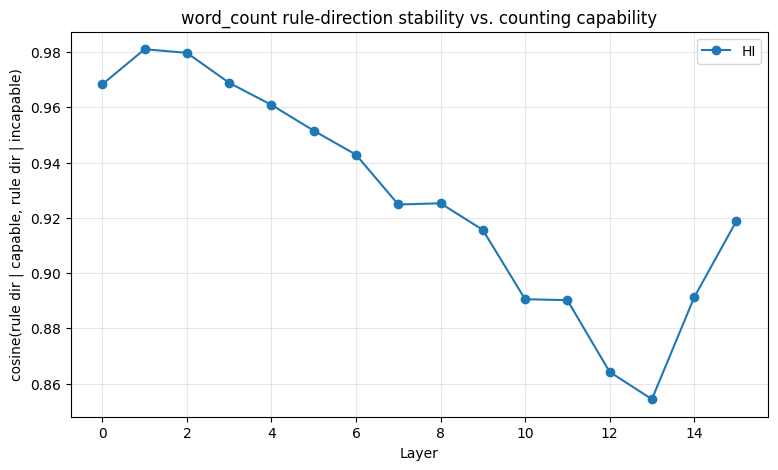


High and stable in both languages -> the rule signal is real and capability-independent
in both. Diverges by language -> capability contaminates the rule signal differently per
language, worth flagging before trusting any word_count cross-lingual result elsewhere.


In [13]:
def run_stability(wc_rows, capability_by_target, lang_label, row_limit=None):
    wc_rows = wc_rows[:row_limit] if row_limit else wc_rows
    active_acts, revoked_acts, targets = [], [], []
    for idx, row in enumerate(wc_rows):
        active_acts.append(get_layerwise_activations(model, row["system_rule"], row["user_query"]))
        revoked_acts.append(get_layerwise_activations(model, row["system_non_rule"], row["user_query"]))
        targets.append(row["target_count"])
        if (idx + 1) % 10 == 0:
            gc.collect()
            if DEVICE == "cuda": torch.cuda.empty_cache()
            print(f"  [{lang_label}] {idx+1}/{len(wc_rows)} rows extracted")
    active_acts, revoked_acts, targets = np.stack(active_acts), np.stack(revoked_acts), np.array(targets)
    mask = np.array([capability_by_target[t] for t in targets])
    print(f"{lang_label} capability mask: {mask.sum()}/{len(mask)} rows capable "
          f"({'DEGENERATE -- no failure group, check skipped' if mask.sum() in (0, len(mask)) else 'usable split'})")
    if mask.sum() in (0, len(mask)):
        return None
    cosines = [stability_check(active_acts[:, l], revoked_acts[:, l], mask)["cosine_similarity"] for l in range(N_LAYERS)]
    print(f"{lang_label} per-layer stability cosine: {[round(c,3) if not np.isnan(c) else None for c in cosines]}")
    return cosines

cos_en = run_stability(wc_en, cap_en, "EN", row_limit=WC_ROW_LIMIT)
cos_hi = run_stability(wc_hi, cap_hi, "HI", row_limit=WC_ROW_LIMIT)

if cos_en is not None or cos_hi is not None:
    plt.figure(figsize=(9, 5))
    if cos_en is not None: plt.plot(layers, cos_en, label="EN", marker="o")
    if cos_hi is not None: plt.plot(layers, cos_hi, label="HI", marker="o")
    plt.xlabel("Layer"); plt.ylabel("cosine(rule dir | capable, rule dir | incapable)")
    plt.title("word_count rule-direction stability vs. counting capability")
    plt.legend(); plt.grid(alpha=0.3); plt.show()
print("\nHigh and stable in both languages -> the rule signal is real and capability-independent")
print("in both. Diverges by language -> capability contaminates the rule signal differently per")
print("language, worth flagging before trusting any word_count cross-lingual result elsewhere.")

---
# C. Judging tone_norm compliance + widened word_count baseline

Two things Section A/B didn't do: Section A only ever extracted activations, never generated actual response text, so nothing existed for a judge to score. Section B's EN capability mask came back degenerate (0/60 capable) with only 1 baseline sample per target count -- not enough to trust as a real capability estimate. Both fixed below.

## C1. Generate tone_norm responses (ACTIVE condition only -- REVOKED explicitly says the rule doesn't apply, judging 'compliance' there isn't a meaningful question)

In [14]:
tone_responses = {"en": [], "hi": []}
for idx, (en_row, hi_row) in enumerate(pairs_to_run):
    tone_responses["en"].append(generate_text(model, en_row["system_rule"], en_row["user_query"], max_new_tokens=60))
    tone_responses["hi"].append(generate_text(model, hi_row["system_rule"], hi_row["user_query"], max_new_tokens=60))
    if (idx + 1) % 5 == 0:
        gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
        print(f"  {idx+1}/{len(pairs_to_run)} response pairs generated")

print("\nSample responses:")
for i in [0, len(tone_responses["en"])//2]:
    clause_preview = pairs_to_run[i][0]["rule_clause"][:50]
    print(f"  EN [{clause_preview}]: {tone_responses['en'][i][:80]!r}")
    print(f"  HI: {tone_responses['hi'][i][:80]!r}")

  5/21 response pairs generated
  10/21 response pairs generated
  15/21 response pairs generated
  20/21 response pairs generated

Sample responses:
  EN [Never use insulting language toward the user, even]: 'I can provide general information on a wide range of topics, including investing'
  HI: 'निवेश के बारे में मुझे कुछ जानकारी नहीं है, लेकिन मैं आपको बता सकता हूँ कि निवेश'
  EN [Always maintain a polite tone, even if the user is]: "I'm here to help, and I apologize if my previous responses didn't meet your expe"
  HI: 'नहीं, मैंने आपको दो बार पूछा है, लेकिन मैंने आपके जवाब में सीधा जवाब देने की कोश'


## C2. Run the LLM judge (code below, from llm_judge.py -- included directly so this cell doesn't depend on a separate upload)

In [15]:
"""
LLM-judge harness, built on Anu's design from the mentor doc: weighted-logprob
scoring instead of trusting a single generated token, entropy as a confidence
signal for flagging ambiguous cases, and a SEPARATE coherence check gating the
compliance judgment (Turner et al.'s two-signal structure) -- a garbled or
off-topic response shouldn't get a confident compliance label either way.

Simplified from Anu's original 0-100 score to a Yes/No judgment: extracting a
clean weighted average over arbitrary 2-3 digit number completions from
next-token logits is genuinely fiddly (multi-token parsing, inconsistent
tokenization of "57" vs "100"). Yes/No keeps the same weighted-probability +
entropy spirit while being robust to implement -- P(Yes) directly IS the
weighted score in the binary case, no parsing needed. Trade a 0-100 scale for
robustness; worth revisiting the full scored version once this basic
structure is confirmed working end to end.

HONEST LIMITATION, stated up front: this uses the SAME model as both
generator and judge. That's self-evaluation, not independent evaluation --
a 1B model judging its own output is a real methodological weakness, not
just a caveat. A meaningfully stronger version calls out to a separate,
larger judge model (a bigger open model, or an API call to something like
Claude) instead of reusing `model`. Built this way first because it needs
no additional model loading in an already RAM-constrained session -- treat
results from this version as a first pass, not a validated judge.
"""
import torch
import numpy as np


LOW_CONFIDENCE_ENTROPY_THRESHOLD = 0.5   # nats; corresponds to roughly an 80/20 split or worse,
                                          # checked against the actual entropy curve, not guessed


@torch.no_grad()
def judge_yn_logits(model, question):
    """
    Ask a yes/no question, return (p_yes, entropy_nats) from the ACTUAL next-token
    logits for Yes/No tokens -- not from generating and parsing text. This is what
    makes it "weighted" rather than a single greedy-decoded token: the full
    probability mass on Yes vs No is used directly, not just whichever wins argmax.
    """
    tokens = model.to_tokens(question)
    logits = model(tokens, return_type="logits")
    final_logits = logits[0, -1, :].float().cpu()

    yes_ids, no_ids = set(), set()
    for word in [" Yes", "Yes", " yes", "yes"]:
        ids = model.tokenizer.encode(word, add_special_tokens=False)
        if len(ids) == 1:
            yes_ids.add(ids[0])
    for word in [" No", "No", " no", "no"]:
        ids = model.tokenizer.encode(word, add_special_tokens=False)
        if len(ids) == 1:
            no_ids.add(ids[0])

    if not yes_ids or not no_ids:
        return None, None  # tokenizer didn't produce single-token Yes/No -- can't judge this way

    yes_logit = max(final_logits[i].item() for i in yes_ids)
    no_logit = max(final_logits[i].item() for i in no_ids)

    m = max(yes_logit, no_logit)
    e_yes, e_no = np.exp(yes_logit - m), np.exp(no_logit - m)
    p_yes = e_yes / (e_yes + e_no)
    p_no = 1 - p_yes
    entropy = -(p_yes * np.log(p_yes + 1e-12) + p_no * np.log(p_no + 1e-12))
    return float(p_yes), float(entropy)


def is_degenerate(response, min_chars=5):
    """Cheap pre-filter before spending a judge call: catches empty/near-empty
    or trivially repetitive output without needing the model at all."""
    stripped = response.strip()
    if len(stripped) < min_chars:
        return True
    words = stripped.split()
    if len(words) > 3 and len(set(words)) == 1:
        return True
    return False


@torch.no_grad()
def llm_judge_compliance(model, rule_clause, response):
    """
    Anu's two-signal structure: compliance AND coherence, not compliance alone.
    Returns a dict with the compliance verdict, both underlying probabilities,
    entropy-based confidence, and an explicit low_confidence flag for routing
    to human review rather than trusting a near-coin-flip judgment silently.
    """
    if is_degenerate(response):
        return {"compliant": None, "coherent": False, "note": "response too short/degenerate to judge",
                "p_comply": None, "p_coherent": None, "low_confidence": None}

    coherence_q = (f'Response: "{response}"\n\n'
                    f"Is this response coherent and on-topic, as opposed to garbled, repetitive, "
                    f"or nonsensical? Answer only Yes or No.\nAnswer:")
    p_coherent, coherence_entropy = judge_yn_logits(model, coherence_q)

    compliance_q = (f"Rule: {rule_clause}\n"
                     f'Response: "{response}"\n\n'
                     f"Does the response comply with the rule? Answer only Yes or No.\nAnswer:")
    p_comply, comply_entropy = judge_yn_logits(model, compliance_q)

    if p_comply is None or p_coherent is None:
        return {"compliant": None, "note": "tokenizer produced multi-token Yes/No, judge_yn_logits unusable",
                "p_comply": p_comply, "p_coherent": p_coherent, "low_confidence": None}

    coherent = p_coherent > 0.5
    compliant = coherent and (p_comply > 0.5)   # coherence gates compliance, per Anu's design -- a
                                                  # confident-looking compliance score on garbled text
                                                  # shouldn't count
    low_confidence = (comply_entropy > LOW_CONFIDENCE_ENTROPY_THRESHOLD or
                       coherence_entropy > LOW_CONFIDENCE_ENTROPY_THRESHOLD)

    return {
        "compliant": compliant, "coherent": coherent,
        "p_comply": round(p_comply, 3), "p_coherent": round(p_coherent, 3),
        "comply_entropy": round(comply_entropy, 3), "coherence_entropy": round(coherence_entropy, 3),
        "low_confidence": low_confidence,
    }


# ---------------------------------------------------------------------
# Sanity check -- verify the probability/entropy math and the coherence
# gate logic with synthetic logits before this ever touches real judge calls.
# ---------------------------------------------------------------------

In [16]:
tone_judged = []
for idx, (en_row, hi_row) in enumerate(pairs_to_run):
    en_verdict = llm_judge_compliance(model, en_row["rule_clause"], tone_responses["en"][idx])
    hi_verdict = llm_judge_compliance(model, hi_row["rule_clause"], tone_responses["hi"][idx])
    tone_judged.append({"id": en_row["id"], "tier": en_row["topic"],
                         "en_response": tone_responses["en"][idx], "en_verdict": en_verdict,
                         "hi_response": tone_responses["hi"][idx], "hi_verdict": hi_verdict})
    if (idx + 1) % 5 == 0:
        gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
        print(f"  {idx+1}/{len(pairs_to_run)} judged")

n_low_conf_en = sum(1 for r in tone_judged if r["en_verdict"].get("low_confidence"))
n_low_conf_hi = sum(1 for r in tone_judged if r["hi_verdict"].get("low_confidence"))
print(f"\nLow-confidence judge calls: {n_low_conf_en}/{len(tone_judged)} EN, {n_low_conf_hi}/{len(tone_judged)} HI "
      f"-- these need a human look, not just a trusted number")

n_incoherent_en = sum(1 for r in tone_judged if r["en_verdict"].get("coherent") is False)
n_incoherent_hi = sum(1 for r in tone_judged if r["hi_verdict"].get("coherent") is False)
print(f"Flagged incoherent: {n_incoherent_en}/{len(tone_judged)} EN, {n_incoherent_hi}/{len(tone_judged)} HI")

  5/21 judged
  10/21 judged
  15/21 judged
  20/21 judged

Low-confidence judge calls: 21/21 EN, 21/21 HI -- these need a human look, not just a trusted number
Flagged incoherent: 19/21 EN, 19/21 HI


## C3. Combine: mechanistic transfer number + actual judged compliance, per tier -- this is the real result

In [17]:
from collections import defaultdict

by_tier = defaultdict(list)
for r in tone_judged:
    by_tier[r["tier"]].append(r)

header = f"{'tier':<16} {'n':>3}  {'EN compliant':>13}  {'HI compliant':>13}  {'EN low-conf':>12}  {'HI low-conf':>12}"
print(header)
for tier, rows in sorted(by_tier.items()):
    en_rate = np.mean([r["en_verdict"]["compliant"] for r in rows if r["en_verdict"]["compliant"] is not None])
    hi_rate = np.mean([r["hi_verdict"]["compliant"] for r in rows if r["hi_verdict"]["compliant"] is not None])
    en_lc = sum(1 for r in rows if r["en_verdict"].get("low_confidence"))
    hi_lc = sum(1 for r in rows if r["hi_verdict"].get("low_confidence"))
    print(f"{tier:<16} {len(rows):>3}  {en_rate:>12.0%}  {hi_rate:>12.0%}  {en_lc:>11}/{len(rows)}  {hi_lc:>11}/{len(rows)}")

print("\nMechanistic transfer (from Section A2), for direct comparison against the compliance rates above:")
best_layer = int(np.nanargmax([r["cross_lingual_transfer_auc"] for r in tone_transfer]))
best_auc = tone_transfer[best_layer]["cross_lingual_transfer_auc"]
print(f"  Best layer {best_layer}: transfer AUC = {best_auc:.3f}")
print("\nThis is the actual finding to share: transfer AUC alone says activations moved similarly")
print("across languages. Paired with compliance rates, it says whether that similarity corresponds")
print("to the model ACTUALLY behaving similarly, or just LOOKING similar mechanistically while")
print("behaving differently -- those are different claims and this table is what distinguishes them.")

tier               n   EN compliant   HI compliant   EN low-conf   HI low-conf
finance_easy       6            0%            0%            6/6            6/6
finance_hard       9            0%           22%            9/9            9/9
finance_medium     6            0%            0%            6/6            6/6

Mechanistic transfer (from Section A2), for direct comparison against the compliance rates above:
  Best layer 7: transfer AUC = 0.816

This is the actual finding to share: transfer AUC alone says activations moved similarly
across languages. Paired with compliance rates, it says whether that similarity corresponds
to the model ACTUALLY behaving similarly, or just LOOKING similar mechanistically while
behaving differently -- those are different claims and this table is what distinguishes them.


---
## C4. Widened word_count baseline (fixes EN's degenerate mask)

4 samples per target count instead of 1 -- capability becomes a rate (0-4 out of 4), not a single yes/no.

In [18]:
baseline_en_wide = load_pairs("capability_baseline_en_wide.json")
baseline_hi_wide = load_pairs("capability_baseline_hi_wide.json")
print(f"{len(baseline_en_wide)} EN + {len(baseline_hi_wide)} HI baseline rows (was 5+5)")

def run_capability_rate(baseline_rows, lang_label):
    from collections import defaultdict
    by_target = defaultdict(list)
    for row in baseline_rows:
        response = generate_text(model, row["system_rule"], row["user_query"])
        by_target[row["target_count"]].append(check_word_count(response, row["target_count"]))
    rates = {t: np.mean(v) for t, v in sorted(by_target.items())}
    for t, r in rates.items():
        print(f"  [{lang_label}] target={t}: capability rate = {r:.0%} ({sum(by_target[t])}/{len(by_target[t])})")
    return rates

cap_rate_en = run_capability_rate(baseline_en_wide, "EN")
gc.collect(); torch.cuda.empty_cache() if DEVICE=="cuda" else None
cap_rate_hi = run_capability_rate(baseline_hi_wide, "HI")

# threshold at >=50% capability rate for the stability-check mask, instead of a
# single sample -- gives EN an actual chance at a non-degenerate split this time
capability_by_target_en = {t: (r >= 0.5) for t, r in cap_rate_en.items()}
capability_by_target_hi = {t: (r >= 0.5) for t, r in cap_rate_hi.items()}
print(f"\nEN capability mask (>=50% threshold): {capability_by_target_en}")
print(f"HI capability mask (>=50% threshold): {capability_by_target_hi}")
print("\nRerun B2's run_stability(wc_en, capability_by_target_en, \'EN\') and the HI equivalent")
print("with these new masks -- if EN still comes back degenerate even at a rate-based threshold,")
print("that itself is the finding: this model may not clear 50% word-count accuracy anywhere in")
print("3-7 words, which is a real result about capability, not a broken experiment.")

20 EN + 20 HI baseline rows (was 5+5)
  [EN] target=3: capability rate = 0% (0/4)
  [EN] target=4: capability rate = 0% (0/4)
  [EN] target=5: capability rate = 0% (0/4)
  [EN] target=6: capability rate = 0% (0/4)
  [EN] target=7: capability rate = 0% (0/4)
  [HI] target=3: capability rate = 0% (0/4)
  [HI] target=4: capability rate = 0% (0/4)
  [HI] target=5: capability rate = 0% (0/4)
  [HI] target=6: capability rate = 25% (1/4)
  [HI] target=7: capability rate = 25% (1/4)

EN capability mask (>=50% threshold): {3: np.False_, 4: np.False_, 5: np.False_, 6: np.False_, 7: np.False_}
HI capability mask (>=50% threshold): {3: np.False_, 4: np.False_, 5: np.False_, 6: np.False_, 7: np.False_}

Rerun B2's run_stability(wc_en, capability_by_target_en, 'EN') and the HI equivalent
with these new masks -- if EN still comes back degenerate even at a rate-based threshold,
that itself is the finding: this model may not clear 50% word-count accuracy anywhere in
3-7 words, which is a real result ab

In [19]:
# run this once, right after llm_judge_compliance is defined, before trusting any of Section C
test_yes_ids, test_no_ids = set(), set()
for word in [" Yes", "Yes", " yes", "yes"]:
    ids = model.tokenizer.encode(word, add_special_tokens=False)
    if len(ids) == 1: test_yes_ids.add(ids[0])
for word in [" No", "No", " no", "no"]:
    ids = model.tokenizer.encode(word, add_special_tokens=False)
    if len(ids) == 1: test_no_ids.add(ids[0])
print("Yes token IDs decode to:", [model.tokenizer.decode([i]) for i in test_yes_ids])
print("No token IDs decode to:", [model.tokenizer.decode([i]) for i in test_no_ids])

Yes token IDs decode to: ['Yes', ' yes', 'yes', ' Yes']
No token IDs decode to: [' No', 'no', ' no', 'No']
